In [46]:
# -----------------------------------------
# Task 1.1 - Bone Segmentation
# -----------------------------------------
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_opening
from skimage.measure import label, regionprops

In [48]:
# Load Image
image_path = "./Downloads/3702_left_knee.nii.gz"
image = sitk.ReadImage(image_path)
image_array = sitk.GetArrayFromImage(image)
print("Image shape:", image_array.shape)

Image shape: (216, 512, 512)


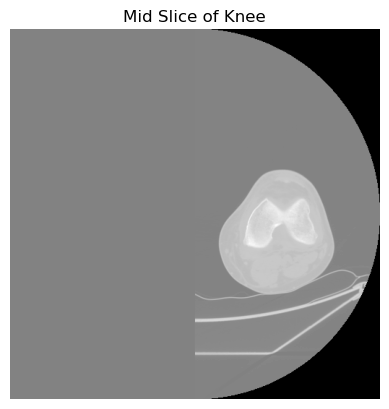

In [50]:
# Visualize mid slice
mid_slice = image_array.shape[0] // 2
plt.imshow(image_array[mid_slice], cmap='gray')
plt.title("Mid Slice of Knee")
plt.axis("off")
plt.show()

In [36]:
# Threshold
threshold = 200
mask = (image_array > threshold).astype(np.uint8)

# Morphological cleaning
mask_cleaned = binary_opening(mask, structure=np.ones((3, 3, 3)))

In [40]:
# Connected Components
labeled = label(mask_cleaned)
regions = sorted(regionprops(labeled), key=lambda r: r.area, reverse=True)[:2]
final_mask = np.zeros_like(mask)
for region in regions:
    final_mask[labeled == region.label] = 1

In [52]:
# Save original mask
original_mask_img = sitk.GetImageFromArray(final_mask)
original_mask_img.CopyInformation(image)
sitk.WriteImage(original_mask_img, "original_mask.nii.gz")

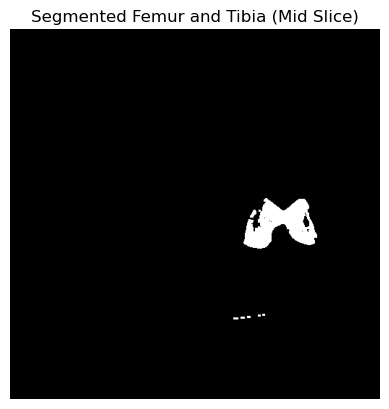

In [54]:
# Show result
plt.imshow(final_mask[mid_slice], cmap='gray')
plt.title("Segmented Femur and Tibia (Mid Slice)")
plt.axis("off")
plt.show()

In [56]:
# -----------------------------------------
# Task 1.2 - Contour Expansion
# -----------------------------------------
from scipy.ndimage import binary_dilation, generate_binary_structure

In [58]:
spacing = image.GetSpacing()
mm_to_pixel = lambda mm: tuple(int(round(mm / s)) for s in spacing[::-1])

In [62]:
def expand_mask(mask, mm):
    pixels = mm_to_pixel(mm)
    struct = generate_binary_structure(3, 1)
    for _ in range(max(pixels)):
        mask = binary_dilation(mask, structure=struct)
    return mask
expanded_2mm = expand_mask(final_mask, 2)
expanded_4mm = expand_mask(final_mask, 4)

In [64]:
# Save masks
sitk.WriteImage(sitk.GetImageFromArray(expanded_2mm.astype(np.uint8)), "2mm_expanded_mask.nii.gz")
sitk.WriteImage(sitk.GetImageFromArray(expanded_4mm.astype(np.uint8)), "4mm_expanded_mask.nii.gz")

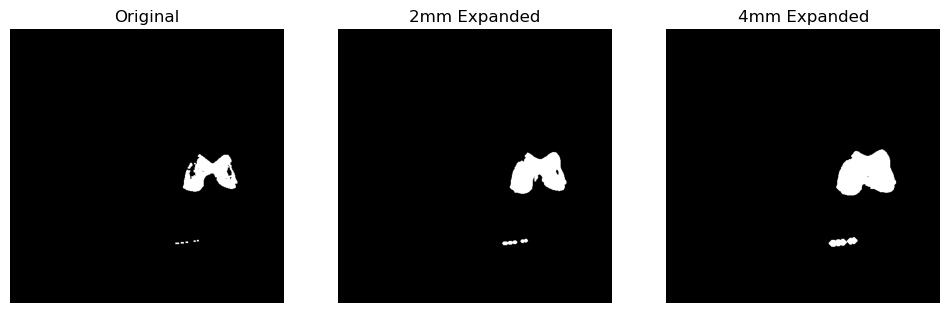

In [66]:
# Show expanded mask comparison
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(final_mask[mid_slice], cmap='gray')
plt.title("Original")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(expanded_2mm[mid_slice], cmap='gray')
plt.title("2mm Expanded")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(expanded_4mm[mid_slice], cmap='gray')
plt.title("4mm Expanded")
plt.axis("off")
plt.show()

In [68]:
# -----------------------------------------
# Task 1.3 - Randomized Contour Adjustment
# -----------------------------------------
def randomize_contour(base_mask, expanded_mask, seed=0):
    np.random.seed(seed)
    diff = (expanded_mask > base_mask).astype(np.uint8)
    random_mask = (np.random.rand(*diff.shape) > 0.5).astype(np.uint8) * diff
    result_mask = np.clip(base_mask + random_mask, 0, 1)
    return result_mask

In [70]:
random_1 = randomize_contour(final_mask, expanded_2mm, seed=42)
random_2 = randomize_contour(final_mask, expanded_2mm, seed=123)

In [72]:
sitk.WriteImage(sitk.GetImageFromArray(random_1.astype(np.uint8)), "randomized_mask_1.nii.gz")
sitk.WriteImage(sitk.GetImageFromArray(random_2.astype(np.uint8)), "randomized_mask_2.nii.gz")

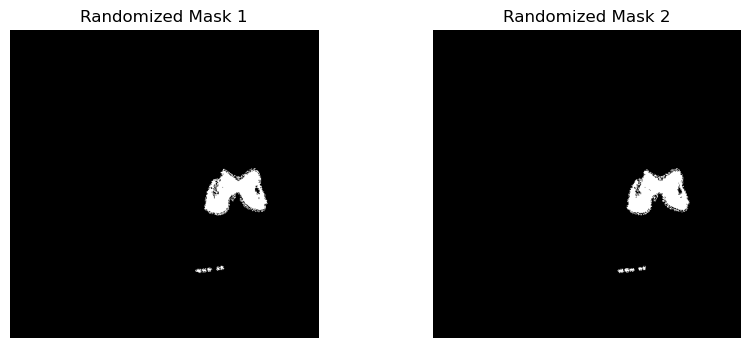

In [74]:
# Show randomized masks
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(random_1[mid_slice], cmap='gray')
plt.title("Randomized Mask 1")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(random_2[mid_slice], cmap='gray')
plt.title("Randomized Mask 2")
plt.axis("off")
plt.show()

In [76]:
# -----------------------------------------
# Task 1.4 - Landmark Detection on Tibia
# -----------------------------------------
from skimage.measure import marching_cubes

In [78]:

def find_landmarks(mask):
    verts, faces, normals, _ = marching_cubes(mask, level=0)
    z_sorted = verts[np.argsort(verts[:, 2])]  # sort by z (height)
    lowest = z_sorted[:10]

    x_mean = np.mean(lowest[:, 0])
    medial = lowest[lowest[:, 0] < x_mean]
    lateral = lowest[lowest[:, 0] >= x_mean]

    medial_point = medial[np.argmin(medial[:, 2])]
    lateral_point = lateral[np.argmin(lateral[:, 2])]
    return medial_point, lateral_point

In [80]:
# Masks to evaluate
masks = {
    "Original": final_mask,
    "2mm": expanded_2mm,
    "4mm": expanded_4mm,
    "Random1": random_1,
    "Random2": random_2
}


In [82]:
# Collect and print landmarks
landmarks = {}
for name, m in masks.items():
    medial, lateral = find_landmarks(m)
    landmarks[name] = {"medial": medial, "lateral": lateral}


In [84]:
# Print landmark coordinates
for name, points in landmarks.items():
    print(f"{name} Mask -> Medial: {points['medial']}, Lateral: {points['lateral']}")


Original Mask -> Medial: [ 44. 400. 301.], Lateral: [ 48. 401. 301.]
2mm Mask -> Medial: [ 40. 401. 299.], Lateral: [ 58. 399. 299.]
4mm Mask -> Medial: [ 48. 400. 296.], Lateral: [ 56. 400. 296.]
Random1 Mask -> Medial: [ 41. 400. 299.], Lateral: [ 48. 401. 299.]
Random2 Mask -> Medial: [ 41. 400. 299.], Lateral: [ 58. 400. 299.]
